In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

# from scipy import optimize

import glob

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [3]:
def f(t, nmax, T):
    res = 0.0
    for n in range(0,nmax):
        res += (n+1.0) * np.exp( -(n+1.0)*t )
        res += (n+1.0) * np.exp( -(n+1.0)*(T-t) )
        res += (n+1.0) * np.exp( -(n+1.0)*(t+T) )
        res += (n+1.0) * np.exp( -(n+1.0)*(2*T-t) )
        res += (n+1.0) * np.exp( -(n+1.0)*(t+2*T) )
        res += (n+1.0) * np.exp( -(n+1.0)*(3*T-t) )
    return res/(4.0*np.pi)

In [4]:
masses_=[]

In [5]:
T=16
Nt=24 # 240

In [6]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

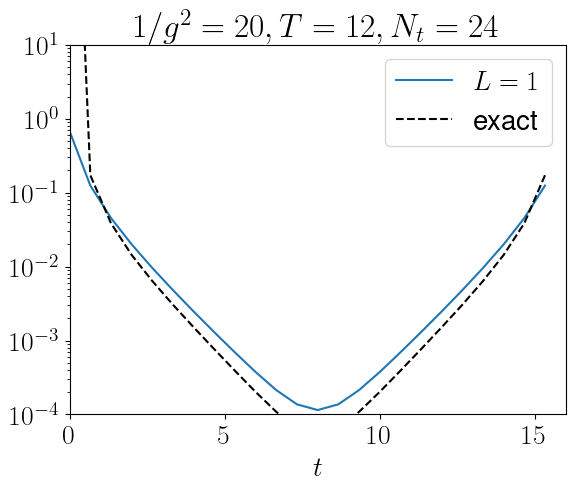

In [7]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [8]:
Nt/T

1.5

In [9]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [10]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [11]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

Text(0, 0.5, '$\\Delta_{\\rm eff}(t)$')

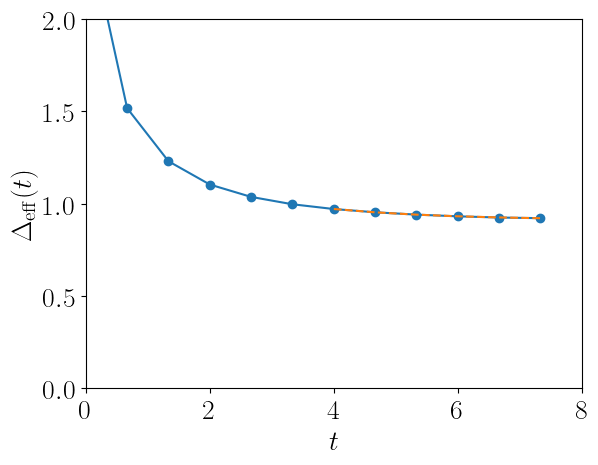

In [12]:
# plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[:fitM], yy[:fitM], marker='o' )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]), 
        ls='dashed')

plt.xlim(0,T/2)
plt.ylim(0,2)

plt.xlabel("$t$")
plt.ylabel("$\\Delta_{\\rm eff}(t)$")
# plt.title("$T=12, L_t="+str(Nt)+", M = 1$")

In [13]:
masses_.append([1, Nt, opt[0][0]])

In [14]:
Nt=48 # 240

In [15]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

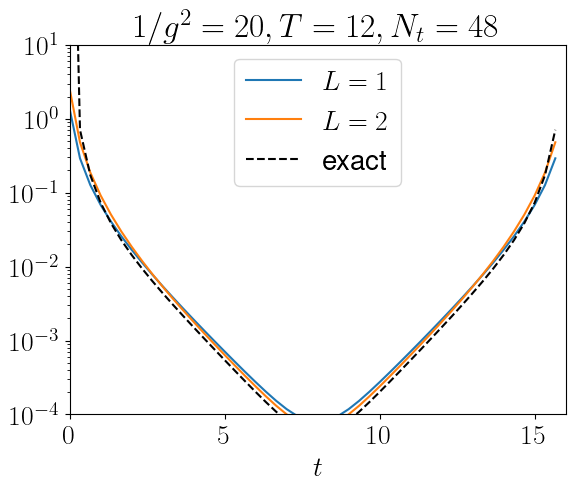

In [16]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [17]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
# fitM = int(8.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [18]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [19]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

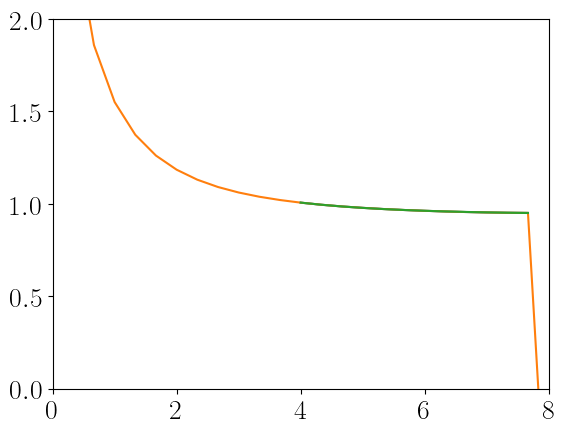

In [20]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [21]:
masses_.append([1, Nt, opt[0][0]])

In [22]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [23]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

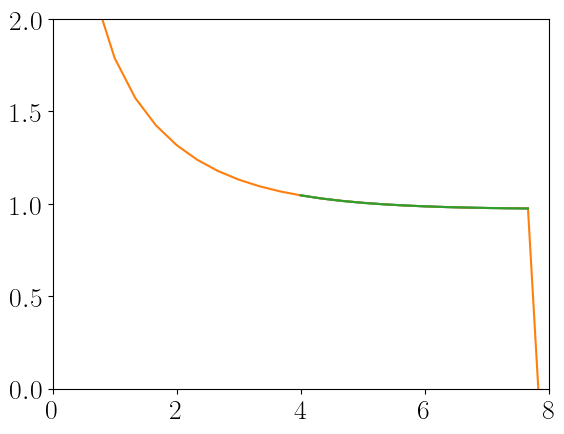

In [24]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [25]:
masses_.append([2, Nt, opt[0][0]])

In [26]:
Nt=64 # 240

In [27]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

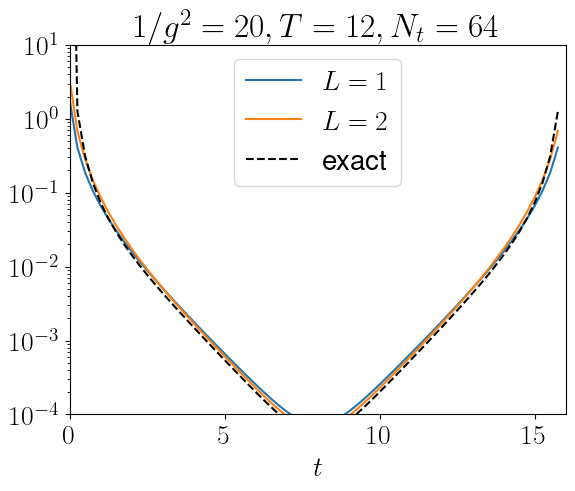

In [28]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [29]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [30]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [31]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

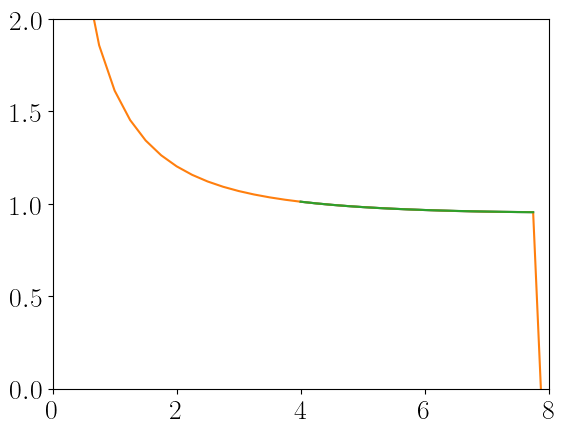

In [32]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [33]:
masses_.append([1, Nt, opt[0][0]])

In [34]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [35]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

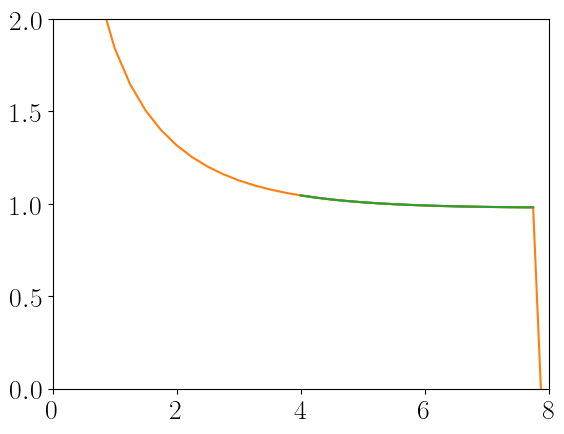

In [36]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [37]:
masses_.append([2, Nt, opt[0][0]])

In [38]:
Nt=96 # 240

In [39]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

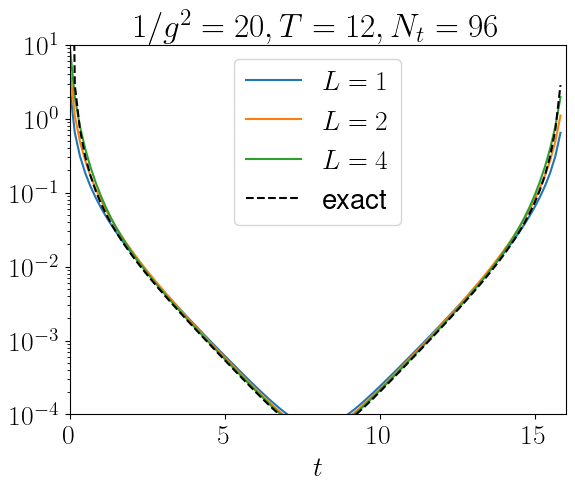

In [40]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [41]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [42]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [43]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

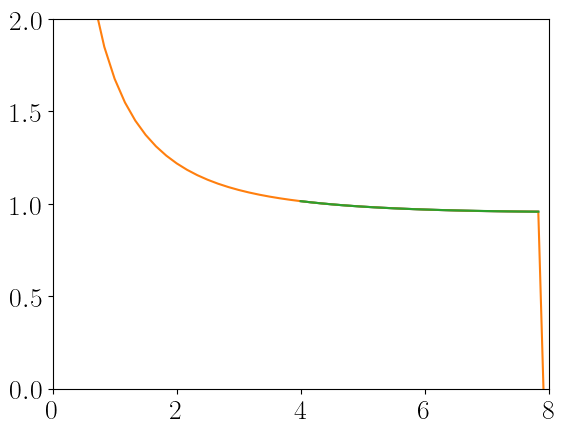

In [44]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [45]:
masses_.append([1, Nt, opt[0][0]])

In [46]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [47]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

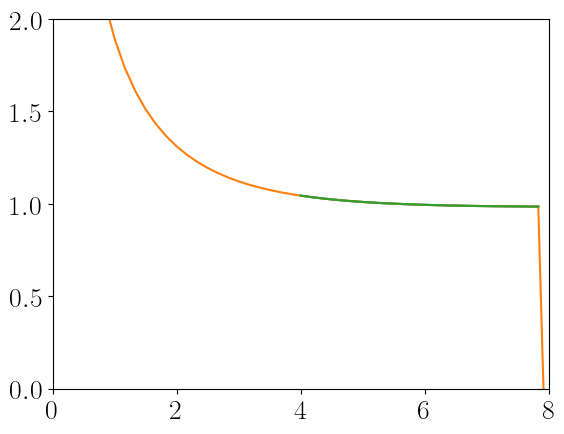

In [48]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [49]:
masses_.append([2, Nt, opt[0][0]])

In [50]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [51]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

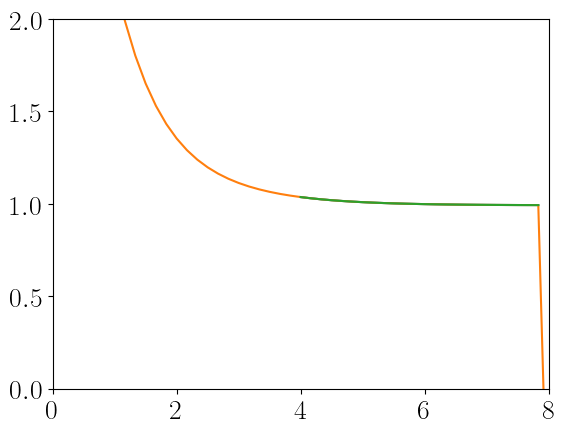

In [52]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [53]:
xx96_4 = xx
yy96_4 = yy
opt96_4 = opt

fitm96 = fitm
fitM96 = fitM

In [54]:
masses_.append([4, Nt, opt[0][0]])

In [55]:
T=16

In [56]:
Nt=120 # 240

In [57]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
# l8_1 = np.loadtxt("ov_prop_temporal_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

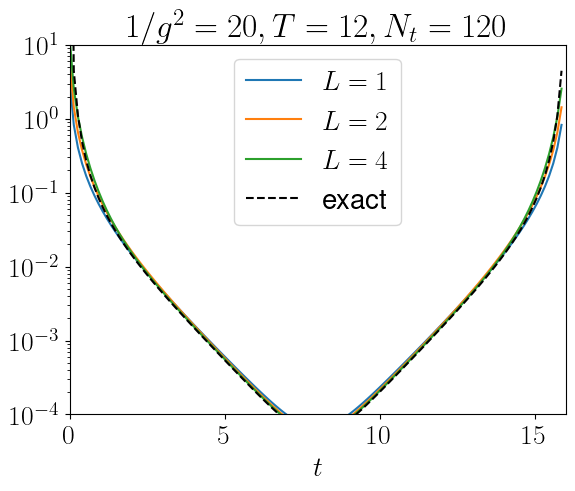

In [58]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
# plt.plot( xx, l8_1, label="$L=8$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [59]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [60]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [61]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

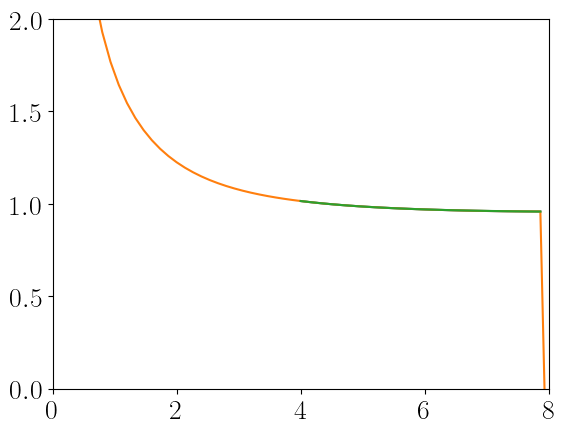

In [62]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [63]:
xx1 = xx
yy1 = yy
opt1 = opt

In [64]:
masses_.append([1, Nt, opt[0][0]])

In [65]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [66]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

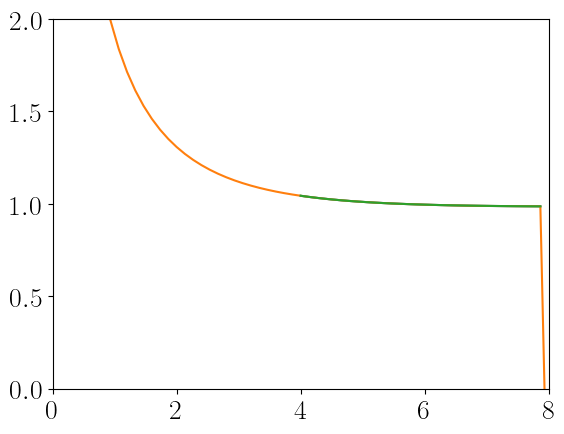

In [67]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [68]:
xx2= xx
yy2 = yy
opt2 = opt

In [69]:
masses_.append([2, Nt, opt[0][0]])

In [70]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [71]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

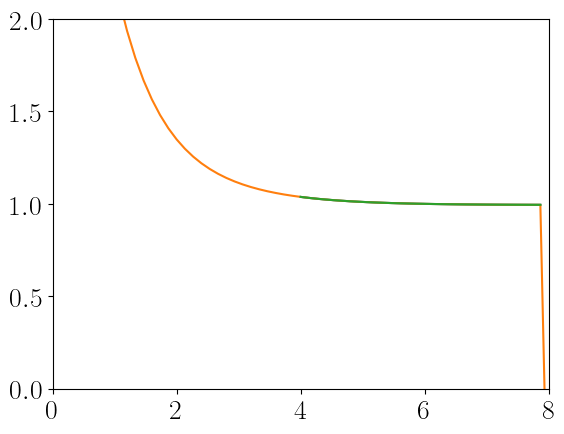

In [72]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [73]:
xx4 = xx
yy4 = yy
opt4 = opt

fitm120 = fitm
fitM120 = fitM

In [74]:
masses_.append([4, Nt, opt[0][0]])

In [75]:
Nt=144 # 240

In [76]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l8_1 = np.loadtxt("ov_prop_temporal_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

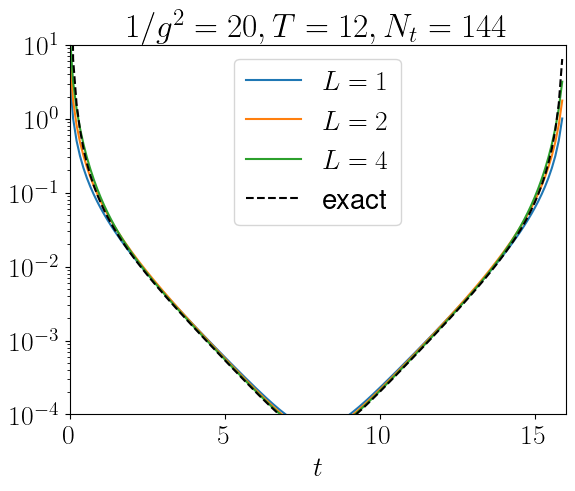

In [77]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
# plt.plot( xx, l8_1, label="$L=8$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [78]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [79]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [80]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

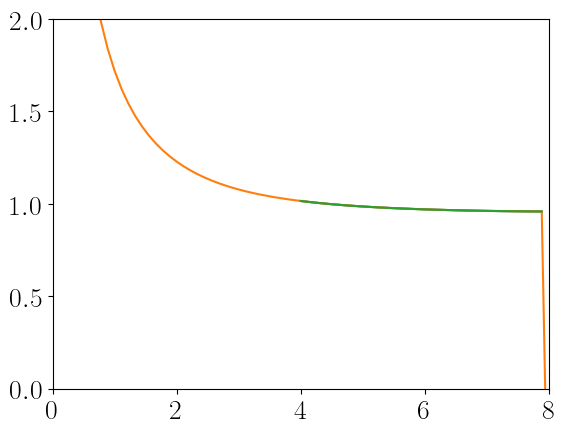

In [81]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [82]:
xx1 = xx
yy1 = yy
opt1 = opt

In [83]:
masses_.append([1, Nt, opt[0][0]])

In [84]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [85]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

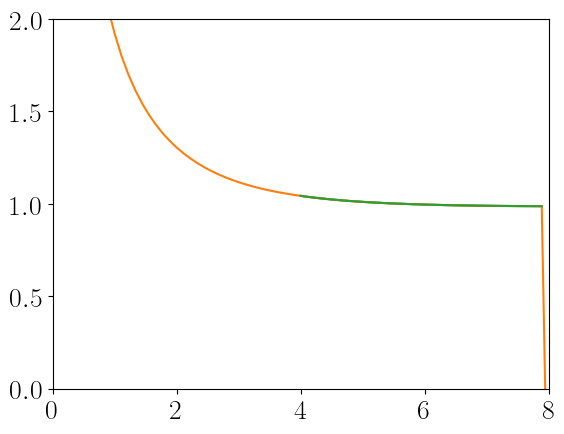

In [86]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [87]:
xx2 = xx
yy2 = yy
opt2 = opt

In [88]:
masses_.append([2, Nt, opt[0][0]])

In [89]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [90]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

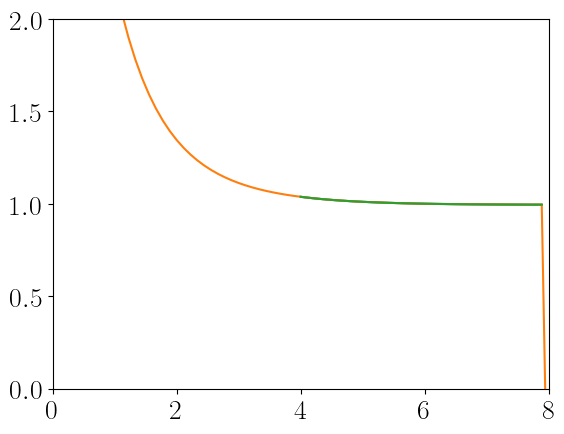

In [91]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [92]:
xx4 = xx
yy4 = yy
opt4 = opt

In [93]:
masses_.append([4, Nt, opt[0][0]])

In [94]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [95]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

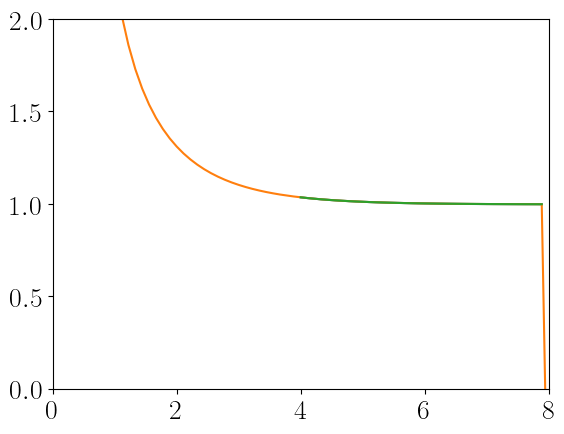

In [96]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [97]:
xx8 = xx
yy8 = yy
opt8 = opt

In [98]:
masses_.append([8, Nt, opt[0][0]])

In [99]:
cs_default = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']

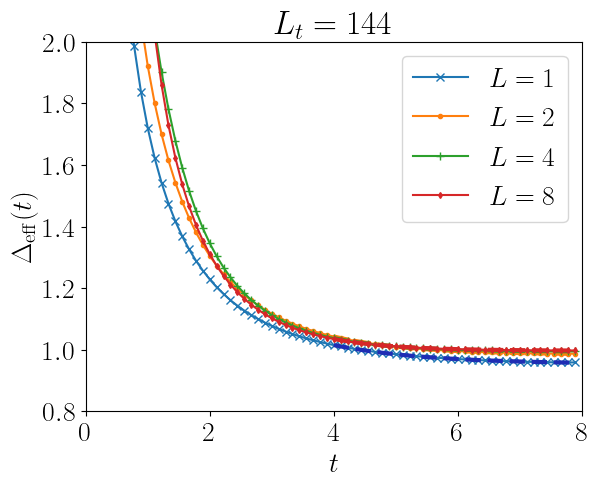

In [100]:
plt.plot( xx1[:fitM], yy1[:fitM], marker='x', label='$L=1$', c=cs_default[0] )
plt.plot( xx1[fitm:fitM], fitter(xx1[fitm:fitM], opt1[0][0], opt1[0][1], opt1[0][2]), 
        ls='dashed', c="#1f2db4", lw=3)


plt.plot( xx2[:fitM], yy2[:fitM], marker='.', label='$L=2$', c=cs_default[1] )
plt.plot( xx2[fitm:fitM], fitter(xx2[fitm:fitM], opt2[0][0], opt2[0][1], opt2[0][2]), 
        ls='dashed', c="#ff7f0e", lw=3)


plt.plot( xx4[:fitM], yy4[:fitM], marker='+', label='$L=4$', c=cs_default[2] )
plt.plot( xx4[fitm:fitM], fitter(xx4[fitm:fitM], opt4[0][0], opt4[0][1], opt4[0][2]), 
        ls='dashed', c="#2ca02c", lw=3)


plt.plot( xx8[:fitM], yy8[:fitM], marker='d', markersize=3, label='$L=8$', c=cs_default[3] )
plt.plot( xx8[fitm:fitM], fitter(xx8[fitm:fitM], opt8[0][0], opt8[0][1], opt8[0][2]), 
        ls='dashed', c="#d62728", lw=3)


# plt.plot( xx96_4[:fitM96], yy96_4[:fitM96], marker='.' )
# plt.plot( xx144_4[:fitM144], yy144_4[:fitM144], marker='.' )


plt.xlim(0,T/2)
plt.ylim(0.8,2)

plt.legend()

plt.title("$L_t=144$")

plt.xlabel("$t$")
plt.ylabel("$\\Delta_{\\rm eff}(t)$")
# plt.title("$T=12, L_t="+str(Nt)+", M = 1$")

plt.savefig("delta_eff_Lt144.pdf", bbox_inches="tight")

In [101]:
# slices=[1,3,5,8,11,15]
# xxx=a_s[slices].T[1]
# yyy=masses.T[2][slices]
# print(yyy)
# lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx[1:]**2, yyy[1:]-lim, label="$L=1$", marker='x' )

# slices=[2,4,6,9,12,16]
# xxx=a_s[slices].T[1]
# yyy=masses.T[2][slices]
# print(yyy)
# lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx[1:]**2, yyy[1:]-lim, label="$L=2$", marker='.' )

# slices=[7,10,13,17]
# xxx=a_s[slices].T[1]
# yyy=masses.T[2][slices]
# print(yyy)
# lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, yyy-lim, label="$L=4$", marker='+' )

# slices=[14,18]
# xxx=a_s[slices].T[1]
# yyy=masses.T[2][slices]
# print(yyy)
# lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, yyy-lim, label="$L=8$", marker='d' )

# plt.xlim(0,0.08)
# plt.legend()

# plt.xlabel("$a_t^2$")
# plt.ylabel("$m(\\bar\\ell, a_t) - m(\\bar\\ell, 0)$")

# plt.savefig("at_scaling_fermion.pdf", bbox_inches="tight")

In [102]:
Nt=168 # 240

In [103]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l8_1 = np.loadtxt("ov_prop_temporal_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

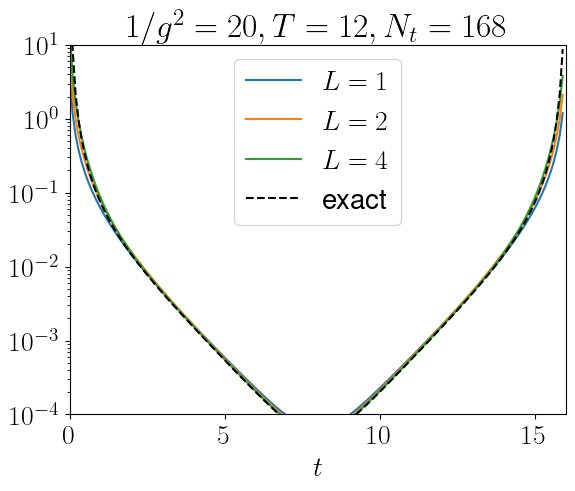

In [104]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
# plt.plot( xx, l8_1, label="$L=8$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [105]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [106]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [107]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

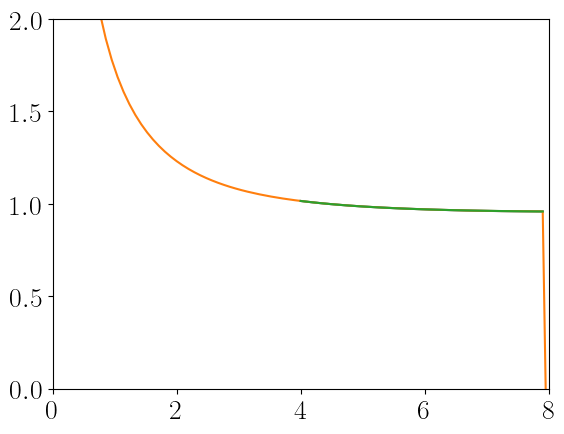

In [108]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [109]:
masses_.append([1, Nt, opt[0][0]])

In [110]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [111]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

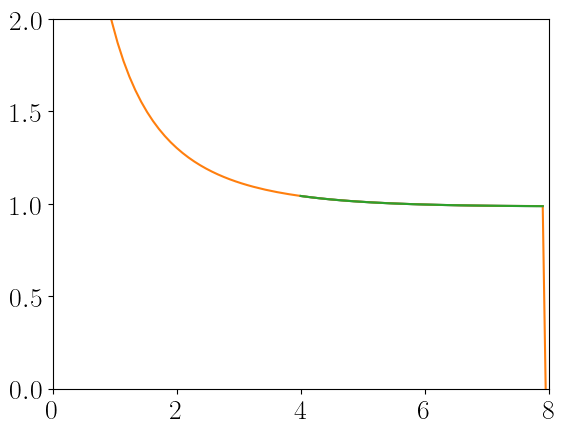

In [112]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [113]:
masses_.append([2, Nt, opt[0][0]])

In [114]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [115]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

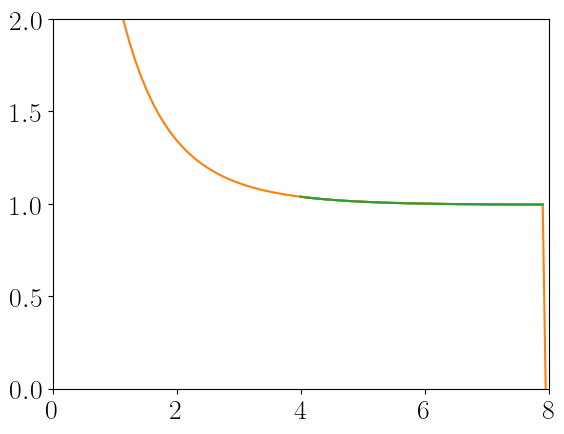

In [116]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [117]:
masses_.append([4, Nt, opt[0][0]])

In [118]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [119]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

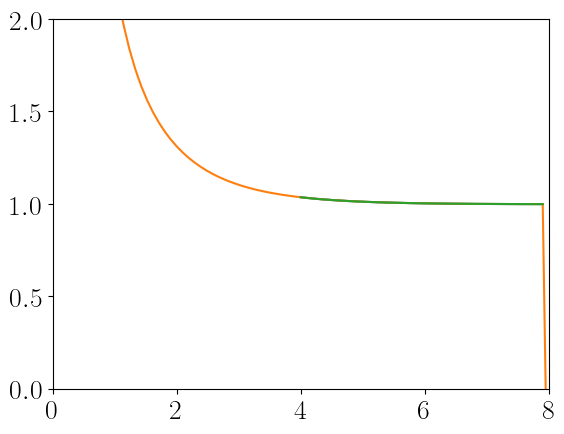

In [120]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [121]:
masses_.append([8, Nt, opt[0][0]])

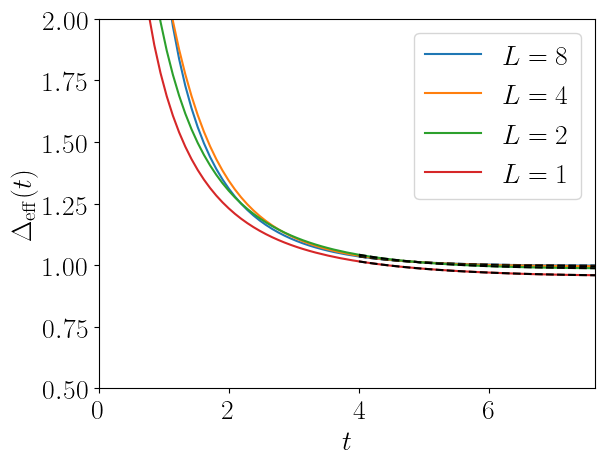

In [122]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM], label="$L=8$" )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]), ls="dashed", color='black' )

##############

tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM], label="$L=4$" )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]), ls="dashed", color='black' )

###############

tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM], label="$L=2$" )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]), ls="dashed", color='black' )

###############

tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM], label="$L=1$" )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]), ls="dashed", color='black' )

###############

plt.xlabel("$t$")
plt.ylabel("$\\Delta_{\\rm eff}(t)$")

plt.xlim(0,T/2.1)
plt.ylim(0.5,2.0)

plt.legend()

plt.savefig("meff_fit.pdf", bbox_inches="tight")

In [123]:
masses = np.array(masses_)
masses

array([[  1.        ,  24.        ,   0.91102761],
       [  1.        ,  48.        ,   0.943444  ],
       [  2.        ,  48.        ,   0.97026383],
       [  1.        ,  64.        ,   0.94853739],
       [  2.        ,  64.        ,   0.9771598 ],
       [  1.        ,  96.        ,   0.95211062],
       [  2.        ,  96.        ,   0.98225393],
       [  4.        ,  96.        ,   0.99211943],
       [  1.        , 120.        ,   0.95311187],
       [  2.        , 120.        ,   0.98375066],
       [  4.        , 120.        ,   0.99370243],
       [  1.        , 144.        ,   0.95362318],
       [  2.        , 144.        ,   0.9845597 ],
       [  4.        , 144.        ,   0.99457261],
       [  8.        , 144.        ,   0.99720757],
       [  1.        , 168.        ,   0.95391225],
       [  2.        , 168.        ,   0.98505121],
       [  4.        , 168.        ,   0.99509318],
       [  8.        , 168.        ,   0.99774589]])

In [124]:
ells={1:1.107148717794090e+00, 
      2:5.909464448075019e-01, 
      4:2.994744726728921e-01,
      8:1.502274914280941e-01, 
      12:1.002118985797942e-01
     }

In [125]:
masses

array([[  1.        ,  24.        ,   0.91102761],
       [  1.        ,  48.        ,   0.943444  ],
       [  2.        ,  48.        ,   0.97026383],
       [  1.        ,  64.        ,   0.94853739],
       [  2.        ,  64.        ,   0.9771598 ],
       [  1.        ,  96.        ,   0.95211062],
       [  2.        ,  96.        ,   0.98225393],
       [  4.        ,  96.        ,   0.99211943],
       [  1.        , 120.        ,   0.95311187],
       [  2.        , 120.        ,   0.98375066],
       [  4.        , 120.        ,   0.99370243],
       [  1.        , 144.        ,   0.95362318],
       [  2.        , 144.        ,   0.9845597 ],
       [  4.        , 144.        ,   0.99457261],
       [  8.        , 144.        ,   0.99720757],
       [  1.        , 168.        ,   0.95391225],
       [  2.        , 168.        ,   0.98505121],
       [  4.        , 168.        ,   0.99509318],
       [  8.        , 168.        ,   0.99774589]])

In [126]:
a_s = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses ])

In [127]:
def fitter( x, c0, cx, ct ):
    return c0 + cx*x[0]**2 + ct*x[1]**2

In [128]:
opt1= sp.optimize.curve_fit( fitter, a_s.T, masses.T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [129]:
opt1

(array([ 0.99806864, -0.03532469, -0.10125524]),
 array([[ 0.12413774, -0.11537302, -0.07921795],
        [-0.11537302,  0.23900286, -0.44968133],
        [-0.07921795, -0.44968133,  6.39789004]]),
 {'fvec': array([-1.26153529e-03,  7.38294175e-05,  4.21822671e-03, -9.74322334e-05,
          2.24437994e-03, -1.54854807e-04,  6.66055930e-04, -3.15254523e-05,
         -1.43559046e-04,  1.81880360e-04, -6.01977667e-04, -1.04841156e-04,
         -7.71248472e-05, -9.22128118e-04, -1.18621515e-03, -6.22563507e-05,
         -2.36992565e-04, -1.11105201e-03, -1.39287766e-03]),
  'nfev': 9,
  'fjac': array([[-4.35889893,  0.22941573,  0.22941573,  0.22941573,  0.22941573,
           0.22941573,  0.22941573,  0.22941573,  0.22941573,  0.22941573,
           0.22941573,  0.22941573,  0.22941573,  0.22941573,  0.22941573,
           0.22941573,  0.22941573,  0.22941573,  0.22941573],
         [-2.54184131, -2.19583231, -0.16114207,  0.23805086, -0.16114207,
           0.23805086, -0.16114207, -0.2

In [130]:
masses2_ = []
for elem in masses:
    if elem[0]!=1:
        masses2_.append(elem)
masses2=np.array(masses2_)

In [131]:
masses2

array([[  2.        ,  48.        ,   0.97026383],
       [  2.        ,  64.        ,   0.9771598 ],
       [  2.        ,  96.        ,   0.98225393],
       [  4.        ,  96.        ,   0.99211943],
       [  2.        , 120.        ,   0.98375066],
       [  4.        , 120.        ,   0.99370243],
       [  2.        , 144.        ,   0.9845597 ],
       [  4.        , 144.        ,   0.99457261],
       [  8.        , 144.        ,   0.99720757],
       [  2.        , 168.        ,   0.98505121],
       [  4.        , 168.        ,   0.99509318],
       [  8.        , 168.        ,   0.99774589]])

In [132]:
a_s2 = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses2 ])

In [133]:
opt2= sp.optimize.curve_fit( fitter, a_s2.T, masses2.T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [134]:
opt2

(array([ 0.99982346, -0.0386413 , -0.14539198]),
 array([[  0.27004507,  -0.75612686,  -1.06648441],
        [ -0.75612686,   5.0867016 , -11.06202165],
        [ -1.06648441, -11.06202165, 122.94070996]]),
 {'fvec': array([-8.92557961e-05,  8.24333292e-05,  3.66349632e-05,  1.99824351e-04,
         -6.17322305e-06,  7.07395213e-05, -2.54233075e-05, -9.65580753e-06,
         -5.11425644e-05, -4.07262484e-05, -5.40149192e-05, -1.13240299e-04]),
  'nfev': 9,
  'fjac': array([[-3.46410161,  0.28867513,  0.28867513,  0.28867513,  0.28867513,
           0.28867513,  0.28867513,  0.28867513,  0.28867513,  0.28867513,
           0.28867513,  0.28867513],
         [-0.72145195, -0.49438614,  0.22123978, -0.30372015,  0.22123978,
          -0.30372015,  0.22123978, -0.30372015, -0.43947758,  0.22123978,
          -0.30372015, -0.43947758],
         [-0.09496551, -0.04448413,  0.0901887 ,  0.0361379 ,  0.43690188,
           0.14701607,  0.49713227,  0.20724646,  0.13228044,  0.53344903,
       

In [135]:
T/96

0.16666666666666666

In [136]:
a_s

array([[1.10714872, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111],
       [1.10714872, 0.0952381 ],
       [0.59094644, 0.0952381 ],
       [0.29947447, 0.0952381 ],
       [0.15022749, 0.0952381 ]])

In [137]:
opt3= sp.optimize.curve_fit( fitter, a_s[5:].T, masses[5:].T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [138]:
opt3

(array([ 0.9993552 , -0.03579371, -0.14483921]),
 array([[ 4.84397387e-01, -1.06383982e-01, -2.27965724e+01],
        [-1.06383982e-01,  3.05268524e-01, -2.50573375e+00],
        [-2.27965724e+01, -2.50573375e+00,  1.51103720e+03]]),
 {'fvec': array([-6.53882813e-04,  5.78154772e-04,  2.30014660e-06, -2.06747352e-04,
          5.29818901e-04, -1.32312368e-04,  6.87229675e-05,  5.07566123e-04,
         -2.15710390e-04, -4.48318183e-04,  2.54062020e-04,  4.90452653e-04,
         -2.61880031e-04, -5.12226446e-04]),
  'nfev': 9,
  'fjac': array([[-3.74165739e+00,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01],
         [-1.79168202e+00,  1.82236360e+00,  2.99988174e-01,
          -3.23429302e-01,  1.57572752e-01,  2.99988174e-01,
          -3.23429302e-01,  1.57572752e-01,  2.999

In [139]:
a_s2

array([[0.59094644, 0.33333333],
       [0.59094644, 0.25      ],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111],
       [0.59094644, 0.0952381 ],
       [0.29947447, 0.0952381 ],
       [0.15022749, 0.0952381 ]])

In [140]:
T/120

0.13333333333333333

In [141]:
0.99997646 - 0.9999543

2.2159999999993296e-05

In [142]:
sp.optimize.curve_fit( fitter, a_s2[2:].T, masses2[2:].T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

(array([ 0.99996718, -0.03854677, -0.15578219]),
 array([[ 6.90271202e-01, -6.17317868e-01, -3.08387421e+01],
        [-6.17317868e-01,  5.29170715e+00, -2.16005843e+01],
        [-3.08387421e+01, -2.16005843e+01,  2.23536724e+03]]),
 {'fvec': array([-7.52528586e-05,  6.34014312e-05, -1.41589689e-05,  3.82186770e-05,
          2.30315805e-05,  1.42639820e-05, -3.35676925e-05,  4.17605617e-05,
          3.93679239e-06, -6.16335048e-05]),
  'nfev': 9,
  'fjac': array([[-3.16227767,  0.31622777,  0.31622777,  0.31622777,  0.31622777,
           0.31622777,  0.31622777,  0.31622777,  0.31622777,  0.31622777],
         [-0.5694462 ,  0.44354824, -0.28972226,  0.29540583, -0.28972226,
           0.29540583,  0.44672398, -0.28972226,  0.29540583,  0.44672398],
         [-0.04912886,  0.00428605, -0.02115074, -0.08712771, -0.23686173,
          -0.34395491, -0.37164995, -0.3917228 , -0.49881599, -0.52651102]]),
  'ipvt': array([1, 2, 3], dtype=int32),
  'qtf': array([ 2.26938945e-09, -1.971261

In [143]:
opt4= sp.optimize.curve_fit( fitter, a_s2[4:].T, masses2[4:].T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [144]:
opt4

(array([ 0.99999891, -0.03865849, -0.15691982]),
 array([[ 1.87051713e+00, -4.86722669e-01, -1.33274952e+02],
        [-4.86722669e-01,  6.49935391e+00, -4.96709071e+01],
        [-1.33274952e+02, -4.96709071e+01,  1.13607692e+04]]),
 {'fvec': array([-4.16696397e-05,  3.97039866e-05,  1.70064675e-06,  2.19290287e-05,
         -1.84041184e-05,  2.41558144e-05,  1.53280257e-05, -4.27437441e-05]),
  'nfev': 9,
  'fjac': array([[-2.82842712e+00,  3.53553391e-01,  3.53553391e-01,
           3.53553391e-01,  3.53553391e-01,  3.53553391e-01,
           3.53553391e-01,  3.53553391e-01],
         [-4.81484661e-01,  3.98974022e-01, -3.31437631e-01,
           3.19062799e-01,  4.87285842e-01, -3.31437631e-01,
           3.19062799e-01,  4.87285842e-01],
         [-3.52858387e-02,  1.74437146e-03,  9.38201519e-03,
           2.17472765e-01,  2.47010503e-01,  4.52370223e-01,
           5.66589482e-01,  5.96127219e-01]]),
  'ipvt': array([1, 2, 3], dtype=int32),
  'qtf': array([ 2.38319479e-09, -3.3

In [145]:
[3,4,5]

[3, 4, 5]

In [146]:
slices=[1]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]

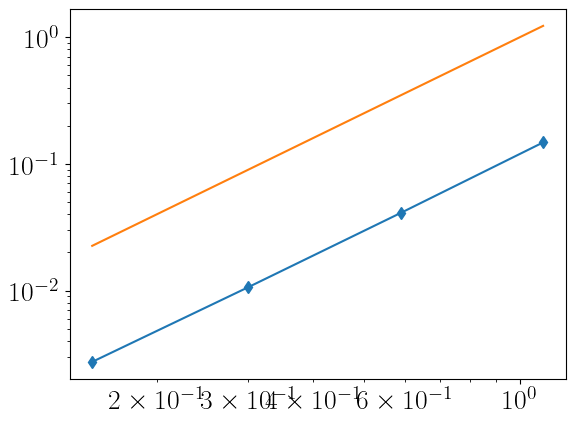

In [147]:
slices=[11,12,13,14]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )*(1-.002)
plt.plot( xxx, yyy-lim, label="$L_t=144$", marker='d' )

plt.plot( xxx, xxx**2 )

plt.xscale("log")
plt.yscale("log")

In [148]:
cs_default = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']

In [149]:
a_s

array([[1.10714872, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111],
       [1.10714872, 0.0952381 ],
       [0.59094644, 0.0952381 ],
       [0.29947447, 0.0952381 ],
       [0.15022749, 0.0952381 ]])

In [150]:
a_s[slices]

array([[1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111]])

In [151]:
a_s[16:][0][1]

0.09523809523809523

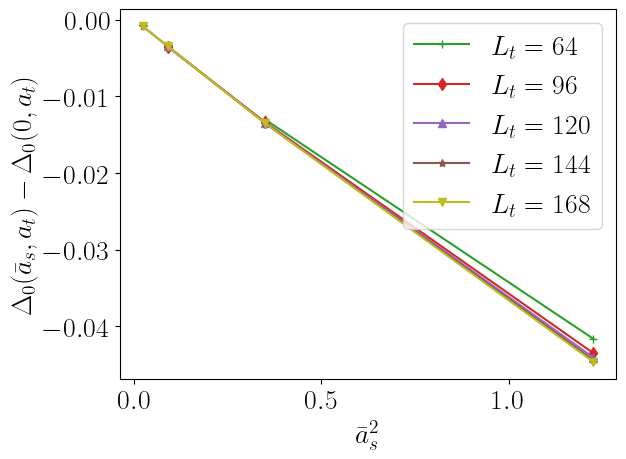

In [156]:
# slices=[1,2]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, yyy-lim, label="$L_t=48$", marker='.' )

slices=[3,4]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=64$", marker='+', c=cs_default[2] )

slices=[5,6,7]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=96$", marker='d', c=cs_default[3] )

slices=[8,9,10]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=120$", marker='^', c=cs_default[4] )

slices=[11,12,13,14]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=144$", marker='*', c=cs_default[5] )

slices=[15,16,17,18]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=168$", marker='v', c=cs_default[8] )

plt.legend()

plt.xlabel("$\\bar{a}_s^2$")
plt.ylabel("$\\Delta_0(\\bar{a}_s, a_t) - \\Delta_0(0, a_t)$")

plt.savefig("ellbar_scaling_fermion.pdf", bbox_inches="tight")

In [153]:
a_s[14:]

array([[0.15022749, 0.11111111],
       [1.10714872, 0.0952381 ],
       [0.59094644, 0.0952381 ],
       [0.29947447, 0.0952381 ],
       [0.15022749, 0.0952381 ]])

[0.943444   0.94853739 0.95211062 0.95311187 0.95362318 0.95391225]
[0.97026383 0.9771598  0.98225393 0.98375066 0.9845597  0.98505121]
[0.99211943 0.99370243 0.99457261 0.99509318]
[0.99720757 0.99774589]


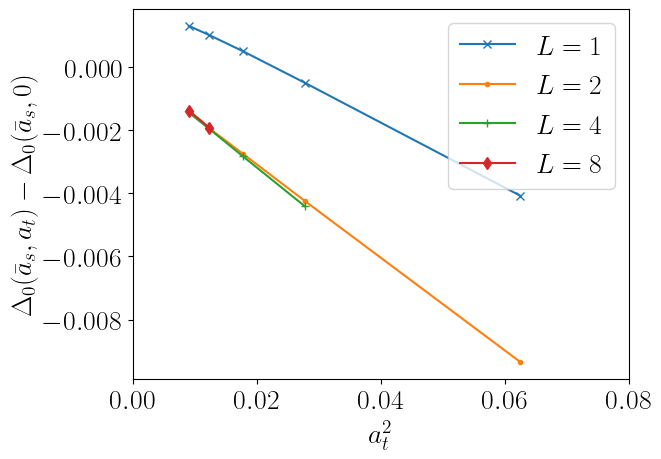

In [154]:
slices=[1,3,5,8,11,15]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx[1:]**2, yyy[1:]-lim, label="$L=1$", marker='x' )

slices=[2,4,6,9,12,16]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx[1:]**2, yyy[1:]-lim, label="$L=2$", marker='.' )

slices=[7,10,13,17]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L=4$", marker='+' )

slices=[14,18]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L=8$", marker='d' )

plt.xlim(0,0.08)
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$\\Delta_0(\\bar{a}_s, a_t) - \\Delta_0(\\bar{a}_s, 0)$")

plt.savefig("at_scaling_fermion.pdf", bbox_inches="tight")

In [137]:
print(masses.T[2][slices])

[0.99708414 0.99747478]


In [138]:
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

NameError: name 'ibase' is not defined

In [ ]:
# slices=[1,2]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, lim-yyy, label="$L_t=48$", marker='d' )

# slices=[3,4]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, lim-yyy, label="$L_t=64$", marker='d' )

# slices=[5,6,7]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, lim-yyy, label="$L_t=96$", marker='d' )

# slices=[8,9,10]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, lim-yyy, label="$L_t=120$", marker='d' )

# slices=[11,12,13,14]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, lim-yyy, label="$L_t=144$", marker='d' )

# plt.legend()

# plt.xlabel("$\\bar{\\ell}^2$")
# plt.ylabel("$m(\\bar\\ell, a_t) - m(0, a_t)$")

# plt.savefig("ellbar_scaling_fermion.pdf", bbox_inches="tight")

In [ ]:
# ibase=0
# lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=1$", marker='d' )

ibase=1
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

ibase=2
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=4$", marker='+' )

ibase=3
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=8$", marker='x' )

# plt.xscale("log")
# plt.yscale("log")
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(\\bar\\ell, 0)$")

plt.savefig("at_scaling_gauge.pdf", bbox_inches="tight")

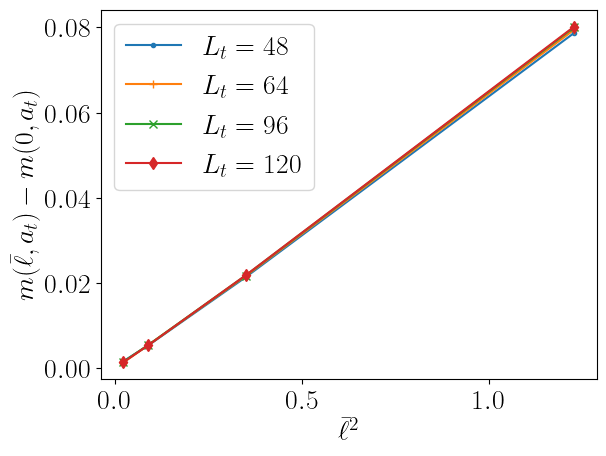

In [241]:
# lim = fitter( [0.0, a_s[:4][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( a_s[:4].T[0]**2, lim-masses.T[2][:4], label="$L_t=24$", marker='x' )

lim = fitter( [0.0, a_s[4:8][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[4:8].T[0]**2, lim-masses.T[2][4:8], label="$L_t=48$", marker='.' )

lim = fitter( [0.0, a_s[8:12][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[8:12].T[0]**2, lim-masses.T[2][8:12], label="$L_t=64$", marker='+' )

lim = fitter( [0.0, a_s[12:16][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[12:16].T[0]**2, lim-masses.T[2][12:16], label="$L_t=96$", marker='x' )

lim = fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[16:].T[0]**2, lim-masses.T[2][16:], label="$L_t=120$", marker='d' )

plt.legend()

plt.xlabel("$\\bar{\\ell}^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(0, a_t)$")

plt.savefig("ellbar_scaling_gauge.pdf", bbox_inches="tight")

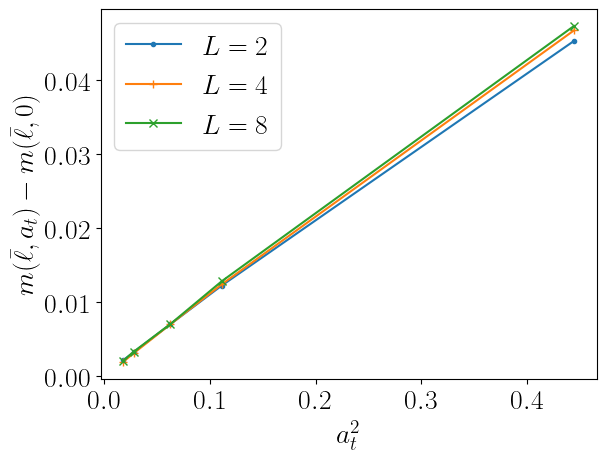

In [242]:
# ibase=0
# lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=1$", marker='d' )

ibase=1
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

ibase=2
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=4$", marker='+' )

ibase=3
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=8$", marker='x' )

# plt.xscale("log")
# plt.yscale("log")
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(\\bar\\ell, 0)$")

plt.savefig("at_scaling_gauge.pdf", bbox_inches="tight")

In [244]:
a_s

array([[1.10714872, 0.66666667],
       [0.59094644, 0.66666667],
       [0.29947447, 0.66666667],
       [0.15022749, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [0.29947447, 0.25      ],
       [0.15022749, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.15022749, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.15022749, 0.13333333]])

In [ ]:
fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )

In [118]:
opt1[0][0]

1.4068732750000403

In [119]:
masses.T[2][::4]

array([1.2930765 , 1.32292346, 1.32765725, 1.33102841, 1.33197963])

In [120]:
a_s[::3].T[0]

array([1.10714872, 0.15022749, 0.29947447, 0.59094644, 1.10714872,
       0.15022749, 0.29947447])

In [121]:
a_s[4:8]

array([[1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333]])

In [122]:
a_s

array([[1.10714872, 0.66666667],
       [0.59094644, 0.66666667],
       [0.29947447, 0.66666667],
       [0.15022749, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [0.29947447, 0.25      ],
       [0.15022749, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.15022749, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.15022749, 0.13333333]])

In [123]:
ibase=1

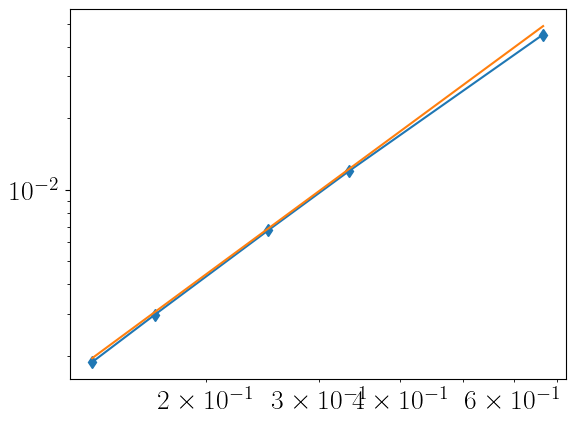

In [124]:
plt.plot( a_s[ibase::4].T[1], 1.3922-masses.T[2][ibase::4], label="$L_t=240$", marker='d' )

plt.plot( a_s[ibase::4].T[1], 0.11*a_s[ibase::4].T[1]**2, label="quad" )

plt.xscale("log")
plt.yscale("log")

In [125]:
ibase=2

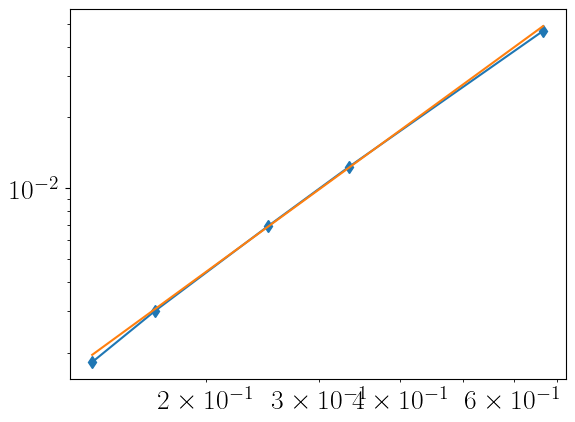

In [126]:
plt.plot( a_s[ibase::4].T[1], 1.4085-masses.T[2][ibase::4], label="$L_t=240$", marker='d' )

plt.plot( a_s[ibase::4].T[1], 0.11*a_s[ibase::4].T[1]**2, label="quad" )

plt.xscale("log")
plt.yscale("log")

In [127]:
ibase=3

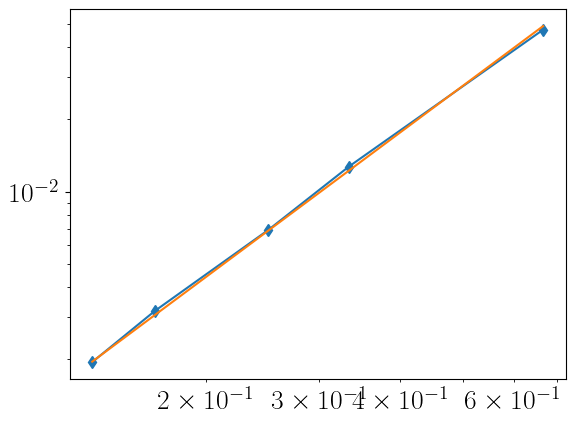

In [128]:
plt.plot( a_s[ibase::4].T[1], 1.41265-masses.T[2][ibase::4], label="$L_t=240$", marker='d' )

plt.plot( a_s[ibase::4].T[1], 0.11*a_s[ibase::4].T[1]**2, label="quad" )

plt.xscale("log")
plt.yscale("log")

In [129]:
a_s[3::4].T[1]

array([0.66666667, 0.33333333, 0.25      , 0.16666667, 0.13333333])

Text(0, 0.5, '$m$')

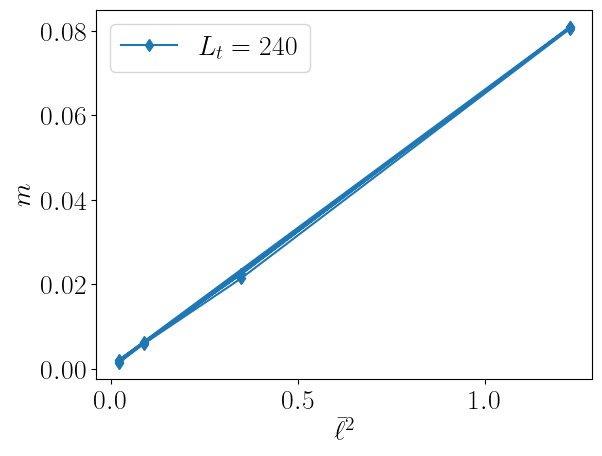

In [144]:
# plt.plot( a_s[:4].T[0], masses.T[2][:4], label="$L_t=96$", marker='x' )
# plt.plot( a_s[4:8].T[0], masses.T[2][4:8], label="$L_t=144$", marker='.' )
# plt.plot( a_s[8:12].T[0], masses.T[2][8:12], label="$L_t=192$", marker='o' )
plt.plot( a_s[12:].T[0]**2, np.sqrt(2.0)-masses.T[2][12:], label="$L_t=240$", marker='d' )

plt.legend()

# xxx=np.linspace( 0.0, 1.2, 100 )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[0][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=96$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[4][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=144$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[7][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=192$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[10][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=240$", ls='dotted' )

# plt.xscale("log")
# plt.yscale("log")

# plt.hlines( np.sqrt(2.0), 0.0, 1.2, ls='dashed' )

plt.xlabel("$\\bar{\\ell}^2$")
plt.ylabel("$m$")

# plt.savefig("m_ellbar.pdf", bbox_inches="tight")

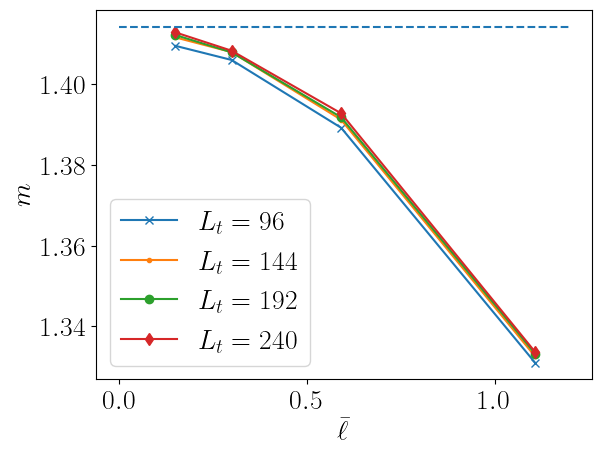

In [103]:
# plt.plot( a_s[:4].T[0], masses.T[2][:4], label="$L_t=96$", marker='x' )
# plt.plot( a_s[4:8].T[0], masses.T[2][4:8], label="$L_t=144$", marker='.' )
# plt.plot( a_s[8:12].T[0], masses.T[2][8:12], label="$L_t=192$", marker='o' )
# plt.plot( a_s[12:].T[0], masses.T[2][12:], label="$L_t=240$", marker='d' )

# plt.legend()

# # xxx=np.linspace( 0.0, 1.2, 100 )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[0][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=96$", ls='dotted' )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[4][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=144$", ls='dotted' )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[7][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=192$", ls='dotted' )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[10][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=240$", ls='dotted' )

# plt.hlines( np.sqrt(2.0), 0.0, 1.2, ls='dashed' )

# plt.xlabel("$\\bar{\\ell}$")
# plt.ylabel("$m$")

# plt.savefig("m_ellbar.pdf", bbox_inches="tight")

In [125]:
a_s[0][1]

0.16666666666666666